In [3]:
!pip install xgboost prophet shap torch scikit-learn --quiet

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')



In [10]:
df = pd.read_csv("5g_dataset-1.csv")
df = df.sort_values(['ue_id', 'timestamp']).reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"UEs: {df['ue_id'].unique()}")
print(f"Timestamp range: {df['timestamp'].min()} → {df['timestamp'].max()}")

Shape: (17525, 14)
UEs: [1 2 3 4 5]
Timestamp range: 1 → 932


In [11]:
print(df.dtypes)
print()
print(df.describe())
df.head(10)

timestamp              int64
ue_id                  int64
sinr_dl_db           float64
mcs_dl                 int64
throughput_mbps      float64
delay_ms             float64
jitter_ms            float64
packet_loss_ratio    float64
prb_utilization        int64
retransmissions        int64
cqi                    int64
load_level             int64
mobility_speed         int64
shadowing_enabled      int64
dtype: object

          timestamp         ue_id    sinr_dl_db        mcs_dl  \
count  17525.000000  17525.000000  17525.000000  17525.000000   
mean     276.287874      3.000000     -5.106792      4.542539   
std      256.273156      1.414254     24.869676      8.848833   
min        1.000000      1.000000    -42.300800      0.000000   
25%       73.000000      2.000000    -18.089600      0.000000   
50%      175.000000      3.000000    -10.988100      0.000000   
75%      450.000000      4.000000     -2.126480      4.000000   
max      932.000000      5.000000     90.978500     28.0000

,timestamp,ue_id,sinr_dl_db,mcs_dl,throughput_mbps,delay_ms,jitter_ms,packet_loss_ratio,prb_utilization,retransmissions,cqi,load_level,mobility_speed,shadowing_enabled
0,1,1,-20.51350,0,0.058944,268.88600,4.166670,0.970000,4,283,0,1,0,0
1,1,1,8.10462,12,1.905860,4.88350,0.183726,0.030000,1,0,7,1,0,1
2,1,1,-14.65900,0,0.117888,347.02900,47.654800,0.970000,4,286,0,2,0,0
3,1,1,8.10462,12,3.831360,4.48662,0.657509,0.025000,1,0,7,2,0,1
4,1,1,-20.51350,0,0.000000,0.00000,0.000000,1.000000,9,149,0,3,0,0
5,1,1,-4.29693,2,0.638560,131.81000,9.177290,0.891667,3,198,2,3,0,1
6,1,1,90.83810,28,5.756860,3.58193,0.449618,0.023333,2,0,15,3,10,0
7,1,1,90.83810,28,5.756860,3.58193,0.449618,0.023333,2,0,15,3,1,0
8,1,1,90.83810,28,5.756860,3.58193,0.449618,0.023333,2,0,15,3,3,0
9,1,1,-24.16020,0,0.009824,339.88600,0.000000,0.998750,7,217,0,4,0,0


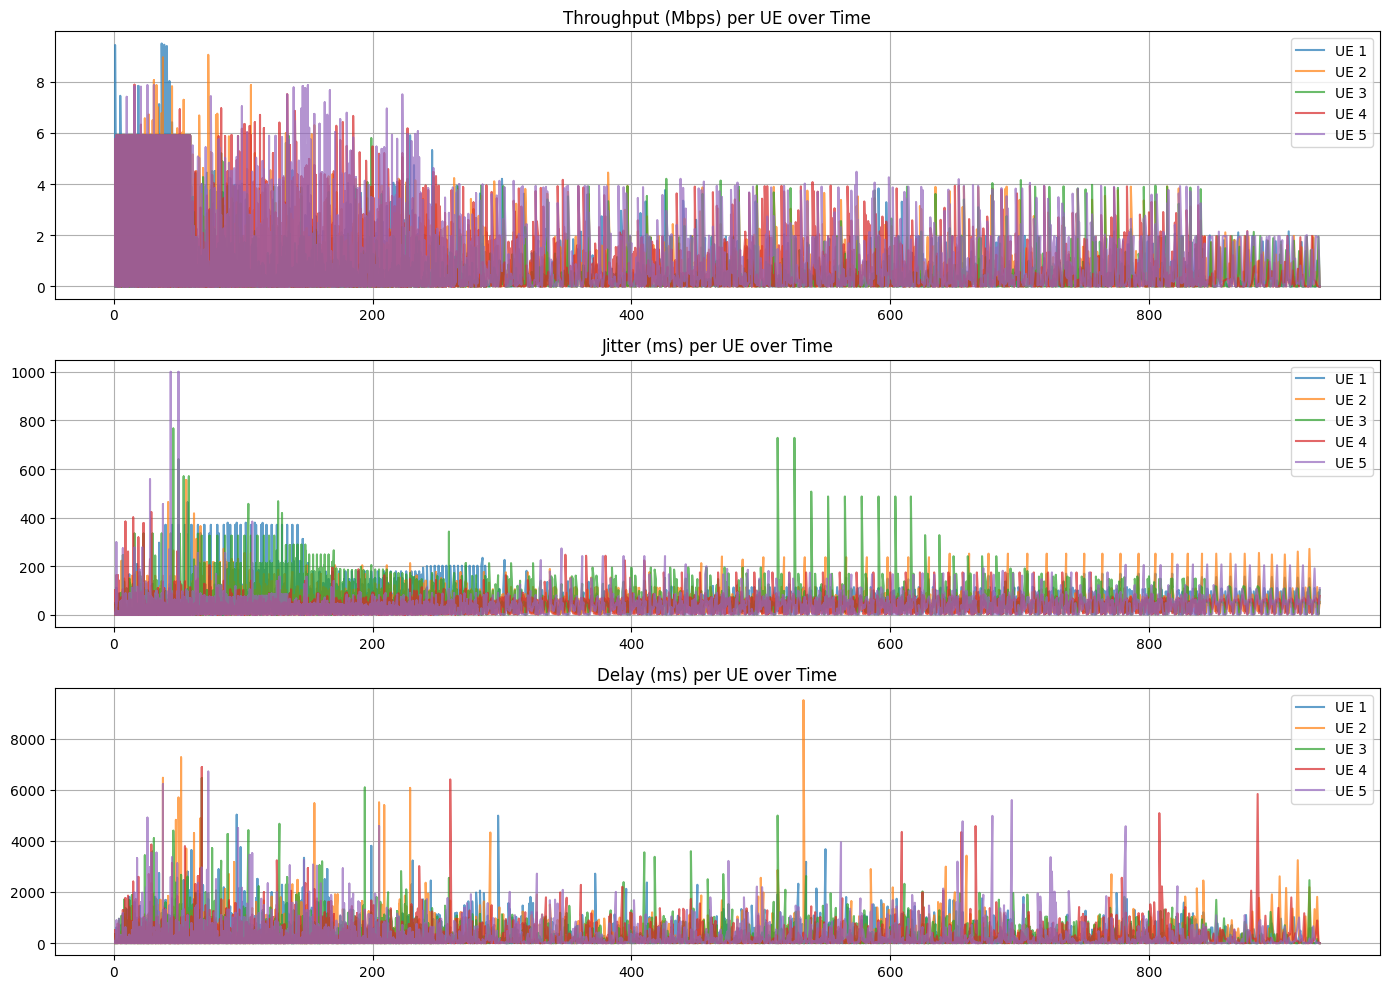

✅ EDA plot saved.


In [12]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ue in df['ue_id'].unique():
    sub = df[df['ue_id'] == ue]
    axes[0].plot(sub['timestamp'], sub['throughput_mbps'], label=f'UE {ue}', alpha=0.7)
    axes[1].plot(sub['timestamp'], sub['jitter_ms'],       label=f'UE {ue}', alpha=0.7)
    axes[2].plot(sub['timestamp'], sub['delay_ms'],        label=f'UE {ue}', alpha=0.7)

axes[0].set_title('Throughput (Mbps) per UE over Time')
axes[1].set_title('Jitter (ms) per UE over Time')
axes[2].set_title('Delay (ms) per UE over Time')

for ax in axes:
    ax.legend(loc='upper right')
    ax.grid(True)

plt.tight_layout()
plt.savefig("eda_qos_per_ue.png")
plt.show()


In [14]:
df = df.sort_values(['ue_id', 'timestamp'])

for col in ['throughput_mbps', 'jitter_ms', 'sinr_dl_db', 'packet_loss_ratio']:
    df[f'{col}_roll3'] = df.groupby('ue_id')[col].transform(lambda x: x.rolling(3, min_periods=1).mean())
    df[f'{col}_roll5'] = df.groupby('ue_id')[col].transform(lambda x: x.rolling(5, min_periods=1).mean())
    df[f'{col}_lag1']  = df.groupby('ue_id')[col].transform(lambda x: x.shift(1))
    df[f'{col}_lag3']  = df.groupby('ue_id')[col].transform(lambda x: x.shift(3))

df = df.dropna().reset_index(drop=True)

print(f"Shape after feature engineering: {df.shape}")
print("New features:", [c for c in df.columns if 'roll' in c or 'lag' in c])

Shape after feature engineering: (17495, 30)
New features: ['throughput_mbps_roll3', 'throughput_mbps_roll5', 'throughput_mbps_lag1', 'throughput_mbps_lag3', 'jitter_ms_roll3', 'jitter_ms_roll5', 'jitter_ms_lag1', 'jitter_ms_lag3', 'sinr_dl_db_roll3', 'sinr_dl_db_roll5', 'sinr_dl_db_lag1', 'sinr_dl_db_lag3', 'packet_loss_ratio_roll3', 'packet_loss_ratio_roll5', 'packet_loss_ratio_lag1', 'packet_loss_ratio_lag3']


In [15]:
DROP_COLS   = ['timestamp', 'ue_id', 'jitter_ms', 'throughput_mbps', 'delay_ms']
FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]

X          = df[FEATURE_COLS]
y_jitter   = df['jitter_ms']
y_throughput = df['throughput_mbps']

# shuffle=False to respect time order
X_train, X_test, y_j_train, y_j_test = train_test_split(X, y_jitter,     test_size=0.2, random_state=42, shuffle=False)
_,       _,      y_t_train, y_t_test = train_test_split(X, y_throughput, test_size=0.2, random_state=42, shuffle=False)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Features used: {FEATURE_COLS}")

Train size: 13996 | Test size: 3499
Features used: ['sinr_dl_db', 'mcs_dl', 'packet_loss_ratio', 'prb_utilization', 'retransmissions', 'cqi', 'load_level', 'mobility_speed', 'shadowing_enabled', 'throughput_mbps_roll3', 'throughput_mbps_roll5', 'throughput_mbps_lag1', 'throughput_mbps_lag3', 'jitter_ms_roll3', 'jitter_ms_roll5', 'jitter_ms_lag1', 'jitter_ms_lag3', 'sinr_dl_db_roll3', 'sinr_dl_db_roll5', 'sinr_dl_db_lag1', 'sinr_dl_db_lag3', 'packet_loss_ratio_roll3', 'packet_loss_ratio_roll5', 'packet_loss_ratio_lag1', 'packet_loss_ratio_lag3']


In [16]:
xgb_jitter = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_jitter.fit(X_train, y_j_train, eval_set=[(X_test, y_j_test)], verbose=100)

y_pred_j = xgb_jitter.predict(X_test)

print("\n📊 XGBoost — Jitter Prediction Results:")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_j_test, y_pred_j)):.4f} ms")
print(f"  MAE  : {mean_absolute_error(y_j_test, y_pred_j):.4f} ms")
print(f"  R²   : {r2_score(y_j_test, y_pred_j):.4f}")

[0]	validation_0-rmse:45.23780
[100]	validation_0-rmse:26.70595
[200]	validation_0-rmse:26.23487
[300]	validation_0-rmse:26.21480
[399]	validation_0-rmse:26.15042

📊 XGBoost — Jitter Prediction Results:
  RMSE : 26.1504 ms
  MAE  : 10.8308 ms
  R²   : 0.6658


In [17]:
pred_jitter_df = X_test.copy()
pred_jitter_df['timestamp'] = df.loc[X_test.index, 'timestamp'].values
pred_jitter_df['ue_id']     = df.loc[X_test.index, 'ue_id'].values
pred_jitter_df['y_true']    = y_j_test.values
pred_jitter_df['y_pred']    = y_pred_j
pred_jitter_df.to_csv("predicted_jitter.csv", index=False)

with open("xgboost_jitter.pkl", "wb") as f:
    pickle.dump(xgb_jitter, f)

print("✅ predicted_jitter.csv saved")
print("✅ xgboost_jitter.pkl saved")

✅ predicted_jitter.csv saved
✅ xgboost_jitter.pkl saved


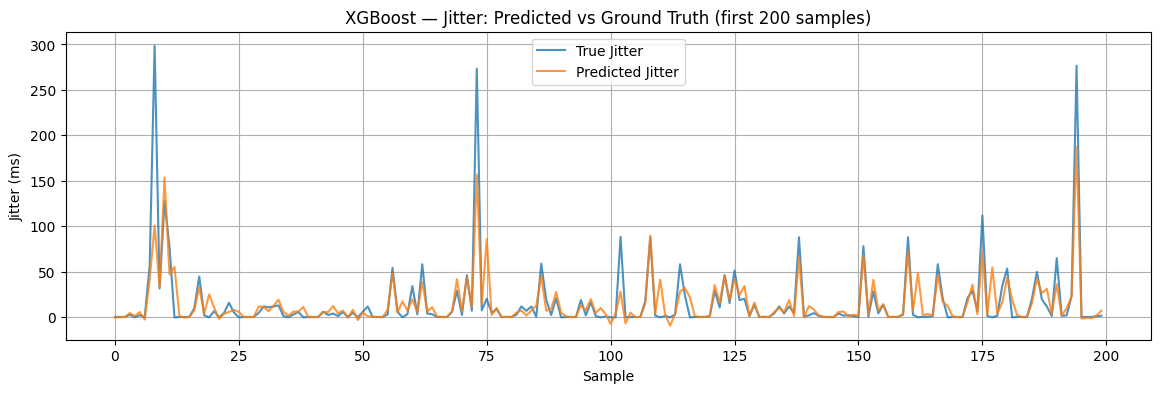

In [18]:
plt.figure(figsize=(14, 4))
plt.plot(y_j_test.values[:200], label='True Jitter',      alpha=0.8)
plt.plot(y_pred_j[:200],        label='Predicted Jitter', alpha=0.8)
plt.title("XGBoost — Jitter: Predicted vs Ground Truth (first 200 samples)")
plt.xlabel("Sample")
plt.ylabel("Jitter (ms)")
plt.legend()
plt.grid(True)
plt.savefig("xgb_jitter_prediction.png")
plt.show()

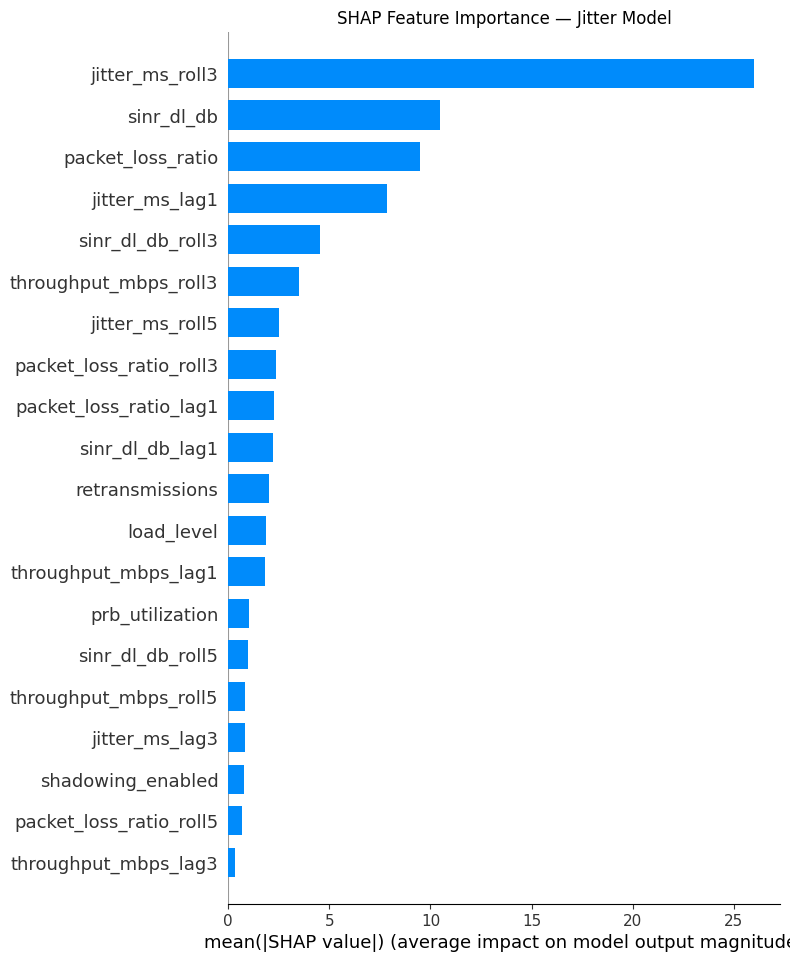

✅ SHAP plot saved.


In [19]:
explainer  = shap.TreeExplainer(xgb_jitter)
shap_values = explainer.shap_values(X_test.iloc[:500])

shap.summary_plot(shap_values, X_test.iloc[:500], plot_type="bar", show=False)
plt.title("SHAP Feature Importance — Jitter Model")
plt.savefig("shap_jitter_importance.png", bbox_inches='tight')
plt.show()
print("✅ SHAP plot saved.")

In [20]:
xgb_throughput = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_throughput.fit(X_train, y_t_train, eval_set=[(X_test, y_t_test)], verbose=100)

y_pred_t = xgb_throughput.predict(X_test)

print("\n📊 XGBoost — Throughput Prediction Results:")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_t_test, y_pred_t)):.4f} Mbps")
print(f"  MAE  : {mean_absolute_error(y_t_test, y_pred_t):.4f} Mbps")
print(f"  R²   : {r2_score(y_t_test, y_pred_t):.4f}")

with open("xgboost_throughput.pkl", "wb") as f:
    pickle.dump(xgb_throughput, f)

print("✅ xgboost_throughput.pkl saved")


[0]	validation_0-rmse:1.64872
[100]	validation_0-rmse:0.09199
[200]	validation_0-rmse:0.06838
[300]	validation_0-rmse:0.06553
[399]	validation_0-rmse:0.06420

📊 XGBoost — Throughput Prediction Results:
  RMSE : 0.0642 Mbps
  MAE  : 0.0284 Mbps
  R²   : 0.9986
✅ xgboost_throughput.pkl saved


In [26]:
WINDOW   = 20
HORIZONS = [1, 3, 5]

scaler_lstm = StandardScaler()

def build_sequences(df, ue_col, ts_col, target_col, window, horizon):
    all_X, all_y = [], []
    for ue in df[ue_col].unique():
        sub    = df[df[ue_col] == ue].sort_values(ts_col)
        series = scaler_lstm.fit_transform(sub[[target_col]].values)
        for i in range(len(series) - window - horizon):
            all_X.append(series[i : i + window])
            all_y.append(series[i + window + horizon - 1])
    return np.array(all_X), np.array(all_y)

print(f"Sequence window: {WINDOW} | Horizons: {HORIZONS}")
print("✅ Sequence builder ready.")

Sequence window: 20 | Horizons: [1, 3, 5]
✅ Sequence builder ready.


In [27]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_size=1, hidden=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc   = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

print("✅ LSTM architecture defined.")

✅ LSTM architecture defined.


In [29]:
results_lstm = {}

for horizon in HORIZONS:
    print(f"\n{'='*40}")
    print(f"🔁 Training LSTM — horizon t+{horizon}")

    all_X, all_y = build_sequences(df, 'ue_id', 'timestamp', 'throughput_mbps', WINDOW, horizon)

    split = int(0.8 * len(all_X))
    X_tr  = torch.tensor(all_X[:split], dtype=torch.float32)
    y_tr  = torch.tensor(all_y[:split], dtype=torch.float32)
    X_te  = torch.tensor(all_X[split:], dtype=torch.float32)
    y_te  = torch.tensor(all_y[split:], dtype=torch.float32)

    model     = LSTMRegressor()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn   = nn.MSELoss()

    for epoch in range(40):
        model.train()
        optimizer.zero_grad()
        loss = loss_fn(model(X_tr), y_tr)
        loss.backward()
        optimizer.step()
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/40 | Loss: {loss.item():.5f}")

    model.eval()
    with torch.no_grad():
        preds = model(X_te).numpy().flatten()
        truth = y_te.numpy().flatten()

    rmse = np.sqrt(mean_squared_error(truth, preds))
    results_lstm[f't+{horizon}'] = rmse
    print(f"  ✅ t+{horizon} RMSE: {rmse:.4f}")

    torch.save(model.state_dict(), f"lstm_throughput_t{horizon}.pt")
    print(f"  💾 lstm_throughput_t{horizon}.pt saved")

print("\n📊 LSTM Summary:")
for k, v in results_lstm.items():
    print(f"  {k}: RMSE = {v:.4f}")


🔁 Training LSTM — horizon t+1
  Epoch 10/40 | Loss: 0.97028
  Epoch 20/40 | Loss: 0.93540
  Epoch 30/40 | Loss: 0.90899
  Epoch 40/40 | Loss: 0.89230
  ✅ t+1 RMSE: 0.9922
  💾 lstm_throughput_t1.pt saved

🔁 Training LSTM — horizon t+3
  Epoch 10/40 | Loss: 0.95898
  Epoch 20/40 | Loss: 0.90689
  Epoch 30/40 | Loss: 0.89378
  Epoch 40/40 | Loss: 0.87465
  ✅ t+3 RMSE: 0.9983
  💾 lstm_throughput_t3.pt saved

🔁 Training LSTM — horizon t+5
  Epoch 10/40 | Loss: 0.96176
  Epoch 20/40 | Loss: 0.92214
  Epoch 30/40 | Loss: 0.89348
  Epoch 40/40 | Loss: 0.87032
  ✅ t+5 RMSE: 0.9860
  💾 lstm_throughput_t5.pt saved

📊 LSTM Summary:
  t+1: RMSE = 0.9922
  t+3: RMSE = 0.9983
  t+5: RMSE = 0.9860


In [30]:
print("📈 Running Prophet forecasting for all UEs...")
forecast_all = []
base = pd.Timestamp("2024-01-01")

for ue in df['ue_id'].unique():
    sub      = df[df['ue_id'] == ue].sort_values('timestamp').copy()
    sub['ds'] = base + pd.to_timedelta(sub['timestamp'], unit='s')

    for metric in ['jitter_ms', 'throughput_mbps']:
        prophet_df = sub[['ds', metric]].rename(columns={metric: 'y'})
        m = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=True)
        m.fit(prophet_df)
        future   = m.make_future_dataframe(periods=50, freq='s')
        forecast = m.predict(future)
        forecast['ue_id']  = ue
        forecast['metric'] = metric
        forecast_all.append(
            forecast[['ds', 'ue_id', 'metric', 'yhat', 'yhat_lower', 'yhat_upper']]
        )
    print(f"  ✅ UE {ue} done")

forecast_ci = pd.concat(forecast_all, ignore_index=True)
forecast_ci.to_csv("forecast_ci.csv", index=False)
print(f"\n✅ forecast_ci.csv saved — {len(forecast_ci)} rows")

📈 Running Prophet forecasting for all UEs...
  ✅ UE 1 done
  ✅ UE 2 done
  ✅ UE 3 done
  ✅ UE 4 done
  ✅ UE 5 done

✅ forecast_ci.csv saved — 9820 rows


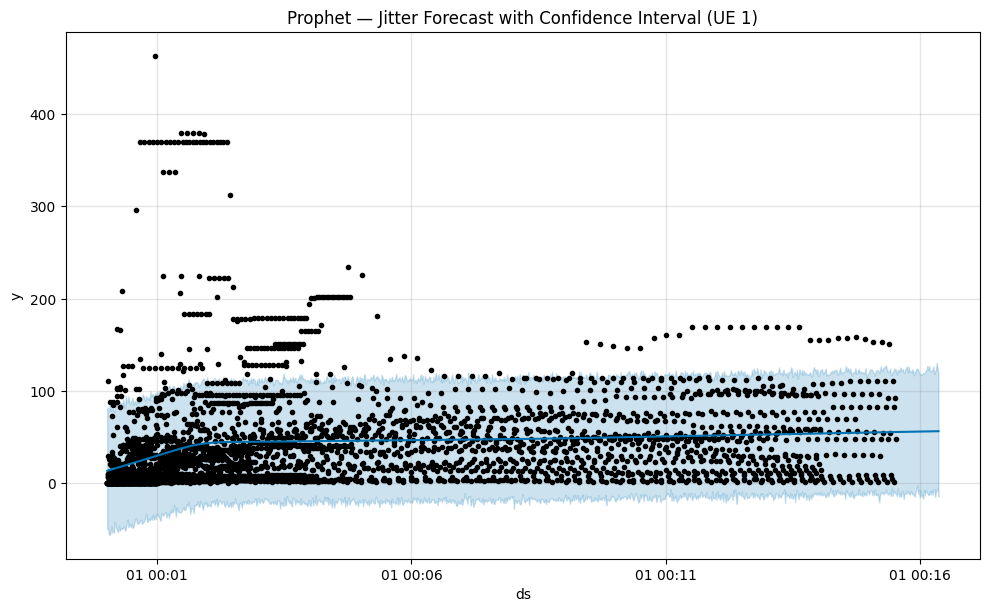

✅ Prophet plot saved.


In [31]:
sub1      = df[df['ue_id'] == 1].sort_values('timestamp').copy()
base      = pd.Timestamp("2024-01-01")
sub1['ds'] = base + pd.to_timedelta(sub1['timestamp'], unit='s')

prophet_plot = sub1[['ds', 'jitter_ms']].rename(columns={'jitter_ms': 'y'})
m_plot = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=True)
m_plot.fit(prophet_plot)

future_plot = m_plot.make_future_dataframe(periods=50, freq='s')
fc_plot     = m_plot.predict(future_plot)

fig = m_plot.plot(fc_plot)
plt.title("Prophet — Jitter Forecast with Confidence Interval (UE 1)")
plt.savefig("prophet_jitter_ue1.png")
plt.show()
print("✅ Prophet plot saved.")


In [33]:
from google.colab import files

output_files = [
    "predicted_jitter.csv",
    "forecast_ci.csv",
    "xgboost_jitter.pkl",
    "xgboost_throughput.pkl",
    "lstm_throughput_t1.pt",
    "lstm_throughput_t3.pt",
    "lstm_throughput_t5.pt",
    "eda_qos_per_ue.png",
    "xgb_jitter_prediction.png",
    "shap_jitter_importance.png",
    "prophet_jitter_ue1.png",
]

print("=" * 50)
print("✅ DSO1.1 — All Models Complete!")
print("=" * 50)
print("\n📁 Downloading all output files...\n")

for f in output_files:
    try:
        files.download(f)
        print(f"  ⬇️  {f}")
    except Exception as e:
        print(f"  ⚠️  {f} — {e}")

✅ DSO1.1 — All Models Complete!

📁 Downloading all output files...



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  predicted_jitter.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇️  shap_jitter_importance.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  prophet_jitter_ue1.png
